In [7]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 2.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.0 MB 3.0 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.0 MB 2.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.0 MB 2.3 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.0 MB 2.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.0 MB 2.5 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 2.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 2.6 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.0 MB 2.7 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.0 MB 2.7 MB/s eta 0:00:01
   ------------------------------

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
image_path = "../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

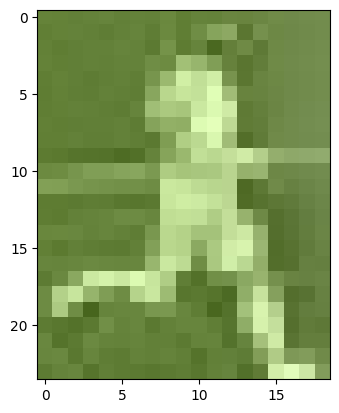

In [4]:
plt.imshow(image)
plt.show()

# Take the top half of the image

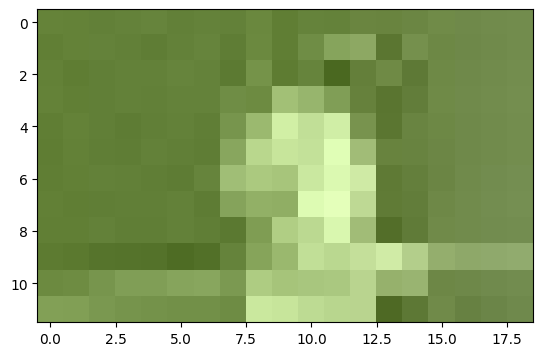

In [5]:
top_half_image=  image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into two clusters

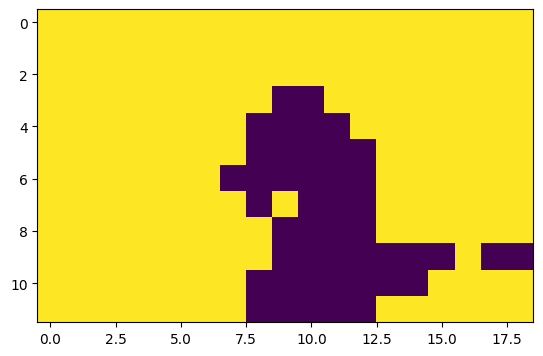

In [9]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the orginal image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [10]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

1


In [11]:
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [12]:
kmeans.cluster_centers_[player_cluster]

array([181.97826087, 210.93478261, 139.82608696])